## Módulo 3. Cálculo de Radiación Solar a partir de Datos Geomáticos

En este módulo se utilizan herramientas de **QGIS Processing**, **GDAL**, **GRASS GIS**, `geopandas` y `rasterio` para resolver dos problemas geomáticos:

- Calcular una **ruta más corta** sobre una red vectorial.
- Estimar la **radiación solar**, las **Horas Sol Pico (PSH)** y la **producción solar diaria** a partir de un modelo digital de elevación.

### **Análisis de redes: ruta más corta entre dos puntos**

Un **análisis de redes** permite estudiar desplazamientos sobre elementos lineales, como calles, caminos, tuberías o ríos. En este ejemplo se calcula la **ruta más corta** entre un punto inicial y un punto final usando una capa de líneas.

El algoritmo `native:shortestpathpointtopoint` de QGIS necesita:

- Una capa de red: `redes.gpkg`.
- Un punto inicial y un punto final.
- Un archivo de salida donde se guardará la ruta: `ruta.gpkg`.

Se usa el proyecto `analisis_redes.qgz` porque ayuda a QGIS a interpretar correctamente el contexto espacial del análisis, como capas, CRS y transformaciones de coordenadas.

In [1]:
import subprocess

cmd = [
    "docker", "exec", "fastapi-qgis",
    "qgis_process",
    "run",
    "native:shortestpathpointtopoint",
    "--PROJECT_PATH=/app/project/analisis_redes.qgz",
    "--",
    "INPUT=/app/data/redes.gpkg",
    "START_POINT=-71.574229,-13.516067 [EPSG:4326]",
    "END_POINT=-71.572639,-13.517401 [EPSG:4326]",
    "OUTPUT=/app/output/ruta.gpkg",
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: 
----------------
Inputs
----------------

END_POINT:	-71.572639,-13.517401 [EPSG:4326]
INPUT:	/app/data/redes.gpkg
OUTPUT:	/app/output/ruta.gpkg
START_POINT:	-71.574229,-13.516067 [EPSG:4326]


Building graph…
0...10...20...30...40...50...60...70...80...90...100 - done.
Calculating shortest path…
Writing results…

----------------
Results
----------------

OUTPUT:	/app/output/ruta.gpkg
TRAVEL_COST:	328.2763079313715

stderr: QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'



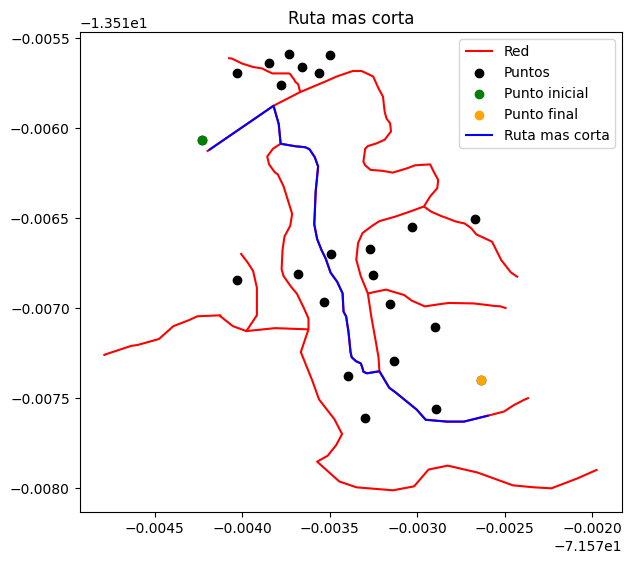

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

red = gpd.read_file("../docker/fastapi-qgis/data/redes.gpkg")
point = gpd.read_file("../docker/fastapi-qgis/data/puntos.gpkg")
rute = gpd.read_file("../docker/fastapi-qgis/output/ruta.gpkg")
point_init = point[
    (point["lat"]==-13.516067) &
    (point["lon"]==-71.574229)
]
point_end = point[
    (point["lat"]==-13.517401) &
    (point["lon"]==-71.572639)
]

fig, ax = plt.subplots(figsize=(7,7))

red.plot(ax=ax, color="red", label="Red")
point.plot(ax=ax, color="black", label="Puntos")
point_init.plot(ax=ax, color="green", label="Punto inicial")
point_end.plot(ax=ax, color="orange", label="Punto final")
rute.plot(ax=ax, color="blue", label="Ruta mas corta")

ax.set_title("Ruta mas corta")
ax.legend()

plt.show()


### **Cálculo de radiación solar a partir de un DEM**

Para estimar la radiación solar se parte de un **Modelo Digital de Elevación (DEM)**. Un DEM es un raster donde cada píxel representa una altura del terreno.

A partir del DEM se calculan tres variables importantes:

- **Pendiente (`slope`)**: indica la inclinación del terreno.
- **Orientación (`aspect`)**: indica hacia dónde mira la ladera.
- **Radiación global (`glob_rad`)**: energía solar recibida por unidad de superficie durante un día.

El flujo de trabajo es:

1. Asignar el CRS correcto al DEM.
2. Calcular pendiente y orientación con `grass:r.slope.aspect`.
3. Calcular insolación y radiación global con `grass:r.sun.insoltime`.

La salida `insolacion.tif` representa horas de sol, mientras que `radiacion_global_diaria.tif` representa radiación en `Wh/m²/día`.

In [3]:
import subprocess

CONTAINER = "fastapi-qgis"
DEM = "/app/data/module03/MDE_talud_modificado.tif"
DEM_CRS = "EPSG:25829"  # ETRS89 / UTM 29N

SLOPE = "/app/output/radiacion_solar/slope.tif"
ASPECT = "/app/output/radiacion_solar/aspect.tif"
INSOLATION = "/app/output/radiacion_solar/insolacion.tif"
GLOBAL_RADIATION = "/app/output/radiacion_solar/radiacion_global_diaria.tif"

DAY_OF_YEAR = 295
TIME_STEP_HOURS = 0.5


def run_cmd(step_name, cmd, expected_outputs=()):
    print(f"\n=== {step_name} ===")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("ERROR")
        print(result.stderr)
        raise RuntimeError(f"Falló: {step_name}")

    for output_path in expected_outputs:
        check = subprocess.run(["docker", "exec", CONTAINER, "test", "-f", output_path])
        if check.returncode != 0:
            raise FileNotFoundError(f"No se generó: {output_path}")

    print("OK")


#Asignar CRS al DEM original
assign_crs_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "gdal:assignprojection",
    "--",
    f"INPUT={DEM}",
    f"CRS={DEM_CRS}",
    f"OUTPUT={DEM}",
]

# Pendiente y orientación del talud.
slope_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.slope.aspect",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
]

# Insolación y radiación global diaria. insol_time (h) y glob_rad (Wh/m2/día).
rsun_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.sun.insoltime",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
    f"insol_time={INSOLATION}",
    f"glob_rad={GLOBAL_RADIATION}",
    f"day={DAY_OF_YEAR}",
    f"step={TIME_STEP_HOURS}",
]

run_cmd("Paso 0 - Asignar CRS al DEM", assign_crs_cmd)
run_cmd("Paso 1 - Calcular slope y aspect", slope_cmd, expected_outputs=(SLOPE, ASPECT))
run_cmd("Paso 2 - Calcular insolación y radiación global", rsun_cmd, expected_outputs=(INSOLATION, GLOBAL_RADIATION),)


=== Paso 0 - Asignar CRS al DEM ===
OK

=== Paso 1 - Calcular slope y aspect ===
OK

=== Paso 2 - Calcular insolación y radiación global ===
OK


### **Horas Sol Pico (PSH) y producción solar estimada**

Las **Horas Sol Pico (PSH)** expresan la radiación solar diaria como horas equivalentes de sol con una intensidad estándar de `1000 W/m²`.

Como el raster de radiación global está en `Wh/m²/día`, el cálculo es:

`PSH = radiación global diaria / 1000`

Después se estima la producción diaria de un sistema fotovoltaico con:

`E = PSH × potencia del sistema × rendimiento`

Donde:

- `E` es la energía producida en `kWh/día`.
- `PSH` son las Horas Sol Pico.
- `potencia del sistema` se expresa en `kWp`.
- `rendimiento` representa pérdidas del sistema, inversor, temperatura, cableado y otros factores.

In [4]:
import numpy as np
import rasterio

RADIACION_GLOBAL_LOCAL = "../docker/fastapi-qgis/output/radiacion_solar/radiacion_global_diaria.tif"

POTENCIA_SISTEMA_KWP = 1.0
RENDIMIENTO_SISTEMA = 0.80

with rasterio.open(RADIACION_GLOBAL_LOCAL) as src:
    radiacion = src.read(1).astype("float64")

    if src.nodata is not None:
        radiacion[radiacion == src.nodata] = np.nan

radiacion_media = np.nanmean(radiacion)
radiacion_min = np.nanmin(radiacion)
radiacion_max = np.nanmax(radiacion)

psh_media = radiacion_media / 1000
psh_min = radiacion_min / 1000
psh_max = radiacion_max / 1000

produccion_kwh_dia = psh_media * POTENCIA_SISTEMA_KWP * RENDIMIENTO_SISTEMA

print("=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===")
print(f"Radiación global media: {radiacion_media:.2f} Wh/m²/día")
print(f"PSH medio: {psh_media:.2f} h")
print(f"PSH mínimo: {psh_min:.2f} h")
print(f"PSH máximo: {psh_max:.2f} h")
print(f"Producción solar estimada: {produccion_kwh_dia:.2f} kWh/día")


=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===
Radiación global media: 4824.87 Wh/m²/día
PSH medio: 4.82 h
PSH mínimo: 0.50 h
PSH máximo: 7.33 h
Producción solar estimada: 3.86 kWh/día


### **Práctica: Análisis de Radiación Solar y Producción Fotovoltaica**

#### Descripción
Modifica los parámetros del modelo de radiación solar y evalúa su impacto en la
producción fotovoltaica estimada. Puedes utilizar el DEM `MDE_talud_modificado.tif`
trabajado en clase o uno de tu elección, asegurándote de que el sistema de referencia
de coordenadas (CRS) sea el correcto antes de ejecutar el análisis.

#### Actividades

1. Cambiar el valor de `DAY_OF_YEAR` y `TIME_STEP_HOURS` para representar otro día del año.
2. Ejecutar el cálculo de pendiente, orientación, insolación y radiación global.
3. Calcular el PSH y la producción solar estimada.
4. Obtener los valores de PSH medio, mínimo y máximo.
5. Visualizar los resultados en Notebook utilizando `matplotlib` o otras librerias de visualización

#### Entregable

Carpeta de datos `outputs/` y Notebook `.ipynb` con todas las visualizaciones ejecutadas y un párrafo de análisis al final:

- Explicar qué zonas del raster tienen mayor potencial solar y por qué.
- Cómo influyen la pendiente y la orientación del terreno en los resultados.

La carpeta de datos debe incluir, como mínimo:

- `slope.tif`
- `aspect.tif`
- `insolacion.tif`
- `radiacion_global_diaria.tif`
- `psh.tif`
- `produccion_solar_estimada.tif`

#### *Extra*

Desarrollar una API utilizando `FastAPI` (integrada en el proyecto) que permita ejecutar el flujo completo de cálculo de radiación solar y estimación de producción fotovoltaica.  

La API debe ser capaz de:
- Recibir los parámetros de entrada (por ejemplo, `DAY_OF_YEAR`, `TIME_STEP_HOURS`, DEM, potencia del sistema, rendimiento).
- Ejecutar el proceso de cálculo (slope, aspect, insolación, radiación, PSH y producción).
- Devolver los resultados (raster generados y estadísticas básicas).